In [3]:
import pandas as pd

df = pd.read_csv("../data/180822-agt-cierre-2013.csv", encoding="latin-1")
df.head()

,AñoAgricola,CveEstado,Estado,CveDDR,DDR,CveCader,Cader,CveMpio,Municipio,CveCultivo,...,Ciclo,CveModa,Modalidad,Sembrada,Cosechada,Siniestrada,Produccion,Rendimiento,Pmr,Valor
0,2013,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,500,...,PERENNES,2,TEMPORAL,241,0,241,0,0,0,0
1,2013,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,700,...,OTOÑO-INVIERNO,1,RIEGO,2,2,0,22,11,"9,000","198,000"
2,2013,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,1500,...,PERENNES,1,RIEGO,"1,900","1,900",0,"186,454.80",98.134,706.68,"131,763,878.06"
3,2013,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,3900,...,OTOÑO-INVIERNO,1,RIEGO,798,798,0,"21,181",26.543,603.77,"12,788,452.37"
4,2013,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,3900,...,PRIMAVERA-VERANO,2,TEMPORAL,313,313,0,"2,497",7.978,470.28,"1,174,289.16"


In [5]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39937 entries, 0 to 39936
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   AñoAgricola   39937 non-null  int64
 1   CveEstado     39937 non-null  int64
 2   Estado        39937 non-null  str  
 3   CveDDR        39937 non-null  int64
 4   DDR           39937 non-null  str  
 5   CveCader      39937 non-null  int64
 6   Cader         39937 non-null  str  
 7   CveMpio       39937 non-null  int64
 8   Municipio     39937 non-null  str  
 9   CveCultivo    39937 non-null  int64
 10  Cultivo       39937 non-null  str  
 11  CveVariedad   39937 non-null  int64
 12  Variedad      23297 non-null  str  
 13  CveUnidad     39937 non-null  int64
 14  UnidadMedida  39937 non-null  str  
 15  CveCiclo      39937 non-null  int64
 16  Ciclo         39937 non-null  str  
 17  CveModa       39937 non-null  int64
 18  Modalidad     39937 non-null  str  
 19  Sembrada      39937 non-null  str  


In [6]:
df[["Sembrada", "Produccion", "Valor"]].head(10)

,Sembrada,Produccion,Valor
0,241,0,0
1,2,22,"198,000"
2,"1,900","186,454.80","131,763,878.06"
3,798,"21,181","12,788,452.37"
4,313,"2,497","1,174,289.16"
5,6,112,"445,200"
6,26,468,"702,000"
7,43,387,"2,322,000"
8,11,89,"469,400.24"
9,102,293,"2,930,000"


In [8]:
df = pd.read_csv("../data/180822-agt-cierre-2013.csv", encoding="latin-1", thousands=",")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39937 entries, 0 to 39936
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AñoAgricola   39937 non-null  int64  
 1   CveEstado     39937 non-null  int64  
 2   Estado        39937 non-null  str    
 3   CveDDR        39937 non-null  int64  
 4   DDR           39937 non-null  str    
 5   CveCader      39937 non-null  int64  
 6   Cader         39937 non-null  str    
 7   CveMpio       39937 non-null  int64  
 8   Municipio     39937 non-null  str    
 9   CveCultivo    39937 non-null  int64  
 10  Cultivo       39937 non-null  str    
 11  CveVariedad   39937 non-null  int64  
 12  Variedad      23297 non-null  str    
 13  CveUnidad     39937 non-null  int64  
 14  UnidadMedida  39937 non-null  str    
 15  CveCiclo      39937 non-null  int64  
 16  Ciclo         39937 non-null  str    
 17  CveModa       39937 non-null  int64  
 18  Modalidad     39937 non-null  str    

In [9]:
sinaloa = df[df["Estado"].str.contains("Sinaloa", case=False)]
sinaloa.shape

(939, 26)

In [10]:
sinaloa["Municipio"].nunique()

18

In [11]:
top_cultivos = (
    sinaloa.groupby("Cultivo")["Valor"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_cultivos

Cultivo
MAIZ GRANO                1.202667e+10
TOMATE ROJO (JITOMATE)    4.122429e+09
CHILE VERDE               3.264912e+09
PAPA                      2.626978e+09
SORGO GRANO               2.095426e+09
FRIJOL                    1.845668e+09
PEPINO                    1.836047e+09
GARBANZO GRANO            1.540953e+09
CAÑA DE AZUCAR            1.000028e+09
BERENJENA                 4.842704e+08
Name: Valor, dtype: float64

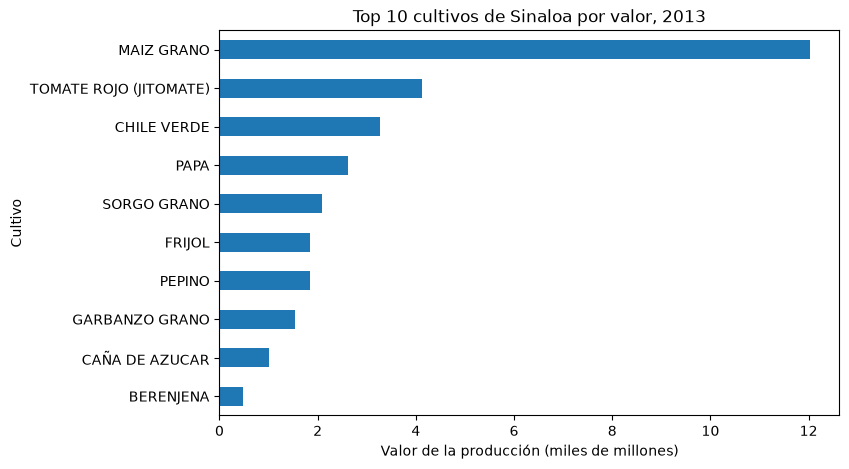

In [13]:
import matplotlib.pyplot as plt

top_mmdp = top_cultivos / 1e9   # miles de millones

top_mmdp.sort_values().plot(kind="barh", figsize=(8, 5))
plt.xlabel("Valor de la producción (miles de millones)")
plt.title("Top 10 cultivos de Sinaloa por valor, 2013")
plt.show()